In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
df = pd.read_csv("powerplant_data.csv")

In [22]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [23]:
# AT => temperature
# V => Vaccum
# AP => pressure
# RH => humidity

# Based on the above four metrics powerplant try to predict how much energy is produced.
# PE => produced energy

In [24]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [25]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [26]:
#Split out data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [27]:
df.shape

(9568, 5)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [29]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [30]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [31]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [32]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Deep Learning

In [33]:
# Building ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        
        self.model = nn.Sequential(
            #hidden
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1),
        )
    
    def forward(self, x):
        return self.model(x)

In [34]:
import torch.optim as optim

model = ANN()

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [35]:
#Train the ANN
train_losses = []
val_losses = []

best_val_loss = float('inf')

epochs = 100

for epoch in range(epochs):
    model.train()
    
    running_loss = 0.0 # Tottal training loss for 1 epoch
    
    for xb, yb in train_loader:
        #xb = features of 1 batch
        #yb = labels og 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # predicted outputs for this batch
        loss = crietrion(outputs, yb) #compute loss
        loss.backward() #compute gradients
        optimizer.step()#parameters update
        
        running_loss += loss.item() #loss is a tensor => py float
        
    epoch_train_loss = running_loss/ len(train_loader)
    train_losses.append(epoch_train_loss)
    
    #Validation
    model.eval()
    running_val_loss = 0.0 # loss while testing the data
    
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss
            
    epoch_val_loss = running_val_loss/ len(test_loader)
    val_losses.append(epoch_val_loss)
    
    print(f"epoch {epoch+1}/{epochs} ==> train_loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train_loss = 206191.6478515625 & val_loss = 203979.359375
epoch 2/100 ==> train_loss = 196765.58033854168 & val_loss = 185251.0
epoch 3/100 ==> train_loss = 165836.6224609375 & val_loss = 142535.984375
epoch 4/100 ==> train_loss = 115774.82985026042 & val_loss = 89327.8671875
epoch 5/100 ==> train_loss = 67033.57057291667 & val_loss = 48075.53515625
epoch 6/100 ==> train_loss = 35612.59532063802 & val_loss = 25704.73828125
epoch 7/100 ==> train_loss = 20436.78463948568 & val_loss = 16225.4736328125
epoch 8/100 ==> train_loss = 14194.572827148437 & val_loss = 12259.314453125
epoch 9/100 ==> train_loss = 11121.984814453124 & val_loss = 9768.5380859375
epoch 10/100 ==> train_loss = 8849.716495768229 & val_loss = 7689.1875
epoch 11/100 ==> train_loss = 6890.050668334961 & val_loss = 5880.9189453125
epoch 12/100 ==> train_loss = 5151.267405192058 & val_loss = 4306.30322265625
epoch 13/100 ==> train_loss = 3691.4110112508138 & val_loss = 3037.62646484375
epoch 14/100 ==> trai

Text(0, 0.5, 'Losses')

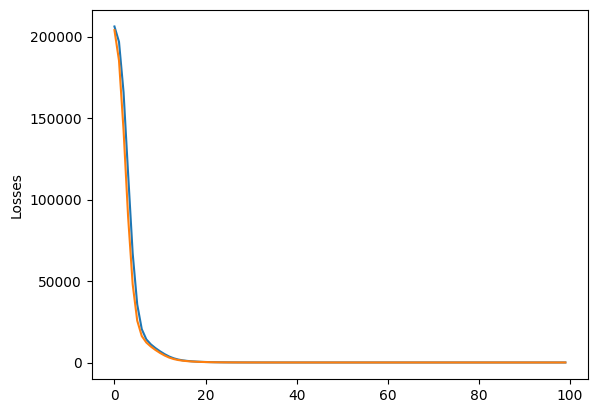

In [36]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Traning Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Traning Loss"], label="Traning Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.ylabel("Epochs")
plt.ylabel("Losses")



In [37]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [40]:
#Evaluating the model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)
    
    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)
    
print("Traning MSE", train_mse_loss.item())
print("Testing MSE", test_mse_loss.item())

Traning MSE 20.11653709411621
Testing MSE 18.148908615112305


In [41]:
from sklearn.metrics import r2_score

print("r^2 score = ", r2_score(y_test, test_preds))

r^2 score =  0.9365742441048678


In [42]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.833221,433.27
1,436.557556,438.16
2,460.934998,458.42
3,476.223328,480.82
4,434.382446,441.41
...,...,...
1909,451.406067,456.70
1910,431.176239,438.04
1911,467.581268,467.80
1912,430.533630,437.14
